# Ejercicio 2: Escalamiento de tickets de soporte técnico

**Curso:** Inteligencia Artificial I - IS484  
**Práctica:** Práctica Calificada 001  
**Estudiante:** Alexis Huamani Rivera

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **P - Medida de desempeño** | Atender los tickets con un nivel de soporte acorde con su urgencia, reduciendo tiempos de espera y priorizando correctamente los casos críticos sin escalar innecesariamente solicitudes simples. |
| **E - Entorno** | Mesa de ayuda donde diferentes clientes generan tickets con distintos niveles de urgencia, tiempos de espera y categorías de servicio. |
| **A - Actuadores** | Mantener en nivel 1, escalar a nivel 2 o escalar a nivel 3. |
| **S - Sensores / Percepciones** | Tiempo de espera del ticket, nivel de urgencia reportado y condición de cliente premium. |

**Objetivo:** asignar cada ticket al nivel de soporte más adecuado, priorizando las incidencias críticas y evitando tiempos de espera excesivos.

### Justificación de las reglas

Las reglas priorizan primero la urgencia del problema, ya que un incidente crítico puede afectar directamente la continuidad del servicio. El tiempo de espera permite evitar que tickets de urgencia media o baja permanezcan sin atención durante demasiado tiempo. La condición de cliente premium funciona como un criterio adicional de prioridad, pero no reemplaza la gravedad real del incidente. De esta manera, el agente combina las tres percepciones antes de seleccionar el nivel de soporte.

#### Reglas de decisión

| Condición | Acción |
|---|---|
| Urgencia **alta** | **Escalar a nivel 3** inmediatamente |
| Urgencia **media** y espera ≥ 30 min | **Escalar a nivel 3** |
| Urgencia **media** y cliente premium | **Escalar a nivel 2** |
| Urgencia **media** sin las condiciones anteriores | **Escalar a nivel 2** |
| Urgencia **baja** y espera ≥ 60 min | **Escalar a nivel 2** |
| Urgencia **baja**, cliente premium y espera ≥ 30 min | **Escalar a nivel 2** |
| Urgencia **baja** en los demás casos | **Mantener en nivel 1** |

In [ ]:
def agente_soporte(tiempo_espera_minutos, nivel_urgencia, cliente_premium):
    """
    Agente reactivo simple 

    Percepciones:
    - tiempo_espera_minutos
    - nivel_urgencia: "baja", "media" o "alta".
    - cliente_premium

    Acciones:
    - mantener en nivel 1
    - escalar a nivel 2
    - escalar a nivel 3
    """

    nivel_urgencia = nivel_urgencia.lower()

    if nivel_urgencia == "alta":
        return (
            "escalar a nivel 3",
            "el ticket presenta urgencia alta y requiere atención inmediata"
        )

    elif nivel_urgencia == "media":
        if tiempo_espera_minutos >= 30:
            return (
                "escalar a nivel 3",
                f"urgencia media con {tiempo_espera_minutos} minutos de espera"
            )
        else:
            return (
                "escalar a nivel 2",
                "el ticket presenta urgencia media y requiere atención especializada"
            )

    elif nivel_urgencia == "baja":
        if tiempo_espera_minutos >= 60:
            return (
                "escalar a nivel 2",
                f"urgencia baja, pero acumula {tiempo_espera_minutos} minutos de espera"
            )

        elif cliente_premium and tiempo_espera_minutos >= 30:
            return (
                "escalar a nivel 2",
                "urgencia baja, pero el cliente es premium y presenta un tiempo de espera considerable"
            )

        else:
            return (
                "mantener en nivel 1",
                "urgencia baja y tiempo de espera dentro del rango normal"
            )

    else:
        return (
            "entrada no válida",
            "el nivel de urgencia debe ser baja, media o alta"
        )

### Simulación y pruebas

Se prueban diferentes combinaciones de urgencia, tiempo de espera y condición del cliente para verificar el comportamiento del agente. Se incluyen casos normales, casos de escalamiento inmediato y situaciones en las que las percepciones entran en conflicto.

In [2]:
casos_prueba = [
    # tiempo_espera, urgencia, cliente_premium
    (10, "baja", False),
    (35, "baja", False),
    (35, "baja", True),
    (75, "baja", False),
    (15, "media", False),
    (35, "media", False),
    (5, "alta", False),
    (75, "baja", True)
]

for i, (espera, urgencia, premium) in enumerate(casos_prueba, start=1):
    accion, motivo = agente_soporte(
        espera,
        urgencia,
        premium
    )

    print(f"Caso {i}")
    print(f"Tiempo de espera: {espera} minutos")
    print(f"Nivel de urgencia: {urgencia}")
    print(f"Cliente premium: {'Sí' if premium else 'No'}")
    print(f"Decisión: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 55)

Caso 1
Tiempo de espera: 10 minutos
Nivel de urgencia: baja
Cliente premium: No
Decisión: mantener en nivel 1
Motivo: urgencia baja y tiempo de espera dentro del rango normal
-------------------------------------------------------
Caso 2
Tiempo de espera: 35 minutos
Nivel de urgencia: baja
Cliente premium: No
Decisión: mantener en nivel 1
Motivo: urgencia baja y tiempo de espera dentro del rango normal
-------------------------------------------------------
Caso 3
Tiempo de espera: 35 minutos
Nivel de urgencia: baja
Cliente premium: Sí
Decisión: escalar a nivel 2
Motivo: urgencia baja, pero el cliente es premium y presenta un tiempo de espera considerable
-------------------------------------------------------
Caso 4
Tiempo de espera: 75 minutos
Nivel de urgencia: baja
Cliente premium: No
Decisión: escalar a nivel 2
Motivo: urgencia baja, pero acumula 75 minutos de espera
-------------------------------------------------------
Caso 5
Tiempo de espera: 15 minutos
Nivel de urgencia: medi

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# Semilla para obtener siempre los mismos resultados
np.random.seed(42)

n = 200

# Datos simulados
flujo_vehicular = np.random.randint(100, 1200, n)
lluvia = np.random.randint(0, 2, n)
hora_pico = np.random.randint(0, 2, n)

# Índice de tráfico observado (datos sintéticos)
ruido = np.random.normal(0, 8, n)

trafico_observado = (
    0.055 * flujo_vehicular
    + 18 * lluvia
    + 25 * hora_pico
    + ruido
)

# Mantener el índice entre 0 y 100
trafico_observado = np.clip(trafico_observado, 0, 100)


# Variables de entrada del modelo
X = np.column_stack([
    flujo_vehicular,
    lluvia,
    hora_pico
])

# Modelo de regresión
modelo = LinearRegression()
modelo.fit(X, trafico_observado)

# Predicciones
trafico_predicho = modelo.predict(X)

# Métrica
r2 = r2_score(trafico_observado, trafico_predicho)

print(f"R² del modelo: {r2:.3f}")

R² del modelo: 0.906


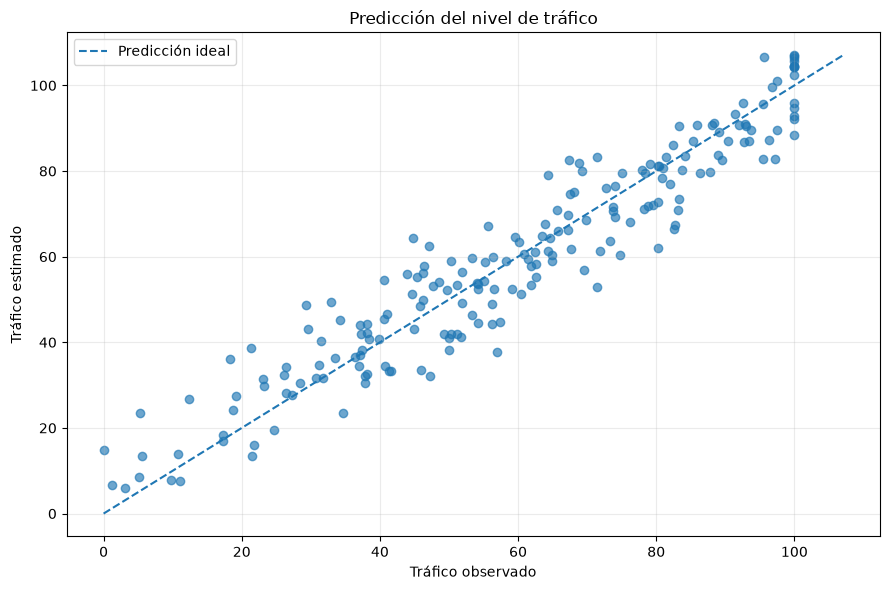

In [4]:
plt.figure(figsize=(9, 6))

plt.scatter(
    trafico_observado,
    trafico_predicho,
    alpha=0.65
)

limite_min = min(
    trafico_observado.min(),
    trafico_predicho.min()
)

limite_max = max(
    trafico_observado.max(),
    trafico_predicho.max()
)

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--",
    label="Predicción ideal"
)

plt.title("Predicción del nivel de tráfico")
plt.xlabel("Tráfico observado")
plt.ylabel("Tráfico estimado")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

# Guardar evidencia dentro del repositorio
Path("evidencias").mkdir(exist_ok=True)

plt.savefig(
    "evidencias/prediccion_trafico.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()